# Project Goal

In this project, I will build and compare two advanced **Gradient Boosting classification models** — **XGBoost** and **LightGBM** — to predict whether a student will:

- **Pass (1)**  
- **Fail (0)**  

based on academic behavior, digital habits, lifestyle, and wellbeing variables.

Dataset; https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

----

## Modeling Focus

The goal is to:

- Transform the original **exam score** into a clear **Pass/Fail binary target**
- Develop a complete machine learning workflow:
  - Data exploration (EDA)
  - Data cleaning and preprocessing
  - Feature engineering and selection
  - Model training and tuning
- Compare **XGBoost vs LightGBM** using a robust validation strategy
- Optimize performance using:
  - **RandomizedSearchCV**
  - **GridSearchCV**
- Evaluate models using:
  - **F1-score (primary metric)**
  - ROC-AUC
  - Confusion matrix

The final objective is to identify the best-performing model and provide **data-driven recommendations** based on the most influential features.

---

# Importing Libraries

In this step, we import the required Python libraries to support:

- Data manipulation and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering and preprocessing
- Model development (XGBoost & LightGBM)
- Hyperparameter tuning (RandomizedSearchCV & GridSearchCV)
- Model evaluation (F1-score, ROC-AUC, confusion matrix)
- Model persistence for reproducibility

These libraries provide the foundation for building a robust Pass/Fail classification pipeline.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

----

# Data Loading

We load the dataset and perform basic checks:
- Shape and preview
- Columns and data types
- Missing values overview

In [41]:
# Load the dataset
students = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')

#Preview the dataset
print("Dataset shape:", students.shape)
display(students.head())

In [42]:
students['exam_score']

0       50.16
1        1.00
2       18.30
3        9.37
4       27.81
        ...  
4995    22.51
4996     2.00
4997    27.89
4998     3.63
4999    10.76
Name: exam_score, Length: 5000, dtype: float64

In [43]:
# Columns Names
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [44]:
# Data Types
students.dtypes

student_id                int64
age                       int64
gender                      str
academic_level              str
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality            str
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [45]:
# Missing values summary --> We have no missing values
missing = students.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 15):\n", missing.head(15))



Missing values (top 15):
 student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
dtype: int64


---

# Data Manipulation and Cleaning

In this section, the dataset is prepared for modeling.  
We remove duplicate records, verify data types, check for unrealistic values, and review missing data.

Missing values will be handled later in the preprocessing pipeline to avoid data leakage.

In [46]:
# Count duplicate rows in the dataset
duplicates = students.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [47]:
# Remove duplicates only if they exist
if duplicates > 0:
    students = students.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", students.shape)

Dataset shape after duplicate removal: (5000, 21)


In [48]:
# Display data types of all columns
students.dtypes

student_id                int64
age                       int64
gender                      str
academic_level              str
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality            str
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [49]:
# Count missing values per column
missing_values = students.isna().sum().sort_values(ascending=False)

missing_values

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [50]:
# Total number of missing entries in the dataset
print("Total missing values in dataset:", students.isna().sum().sum())

Total missing values in dataset: 0


In [51]:
# Change the values of Categorical Variables
students["internet_quality"] = students["internet_quality"].map({
    "Poor": 1,
    "Average": 2,
    "Good": 3
})

students["academic_level"] = students["academic_level"].map({
    "High School":1,
    "Undergraduate":2,
    "Postgraduate":3
})

students['gender'] = students['gender'].map({
    'Male':0,
    'Female':1,
    'Other':2
})

In [52]:
students.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,3,10,43.05,31.77,73.65,50.16
1,2,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,3,3,15.92,37.00,13.70,1.00
2,3,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,3,8,27.39,34.37,45.15,18.30
3,4,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,1,3,22.31,77.31,20.92,9.37
4,5,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,3,8,38.11,39.53,59.23,27.81


---

# Exploratory Data Analysis (EDA)

The purpose of this section is to understand the structure and behavior of the dataset before modeling.

We examine:

- The distribution of `exam_score` and the derived Pass/Fail variable  
- The distribution of key numerical features (study hours, sleep, screen time, stress)  
- The composition of categorical variables  
- Correlations between predictors and `exam_score` to identify influential variables and potential proxy leakage  
- The presence and extent of missing values  

This analysis helps guide feature selection, threshold definition, preprocessing decisions, and modeling strategy.

In [53]:
# First Five Rows
students.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,3,10,43.05,31.77,73.65,50.16
1,2,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,3,3,15.92,37.00,13.70,1.00
2,3,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,3,8,27.39,34.37,45.15,18.30
3,4,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,1,3,22.31,77.31,20.92,9.37
4,5,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,3,8,38.11,39.53,59.23,27.81


In [54]:
# Last Five Rows
students.tail()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
4995,4996,20,2,2,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,3,9,35.55,33.24,48.83,22.51
4996,4997,24,0,1,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,1,5,16.87,59.07,23.32,2.00
4997,4998,22,0,2,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,3,7,23.85,47.72,41.09,27.89
4998,4999,17,0,2,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,3,4,13.04,58.90,12.62,3.63
4999,5000,22,2,2,5.60,4.14,2.17,3.05,2.74,6.38,...,24,219,0,1,3,3,29.98,61.01,34.72,10.76


In [55]:
# Number of Rows and Columns
print(f'The number of rows in this dataset is {students.shape[0]} and the number of columns are {students.shape[1]}')

The number of rows in this dataset is 5000 and the number of columns are 21


In [56]:
# Name of Columns
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [57]:
# Dataset Statistics
students.describe()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,0.986400,2.003000,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,...,74.535600,251.450400,0.498200,0.501400,2.016400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,0.820944,0.819711,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,...,42.932293,143.842712,0.500047,0.500048,0.819918,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,0.000000,1.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,...,37.000000,129.000000,0.000000,0.000000,1.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,1.000000,2.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,...,75.000000,252.000000,0.000000,1.000000,2.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,2.000000,3.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,...,112.000000,376.000000,1.000000,1.000000,3.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,2.000000,3.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,...,149.000000,499.000000,1.000000,1.000000,3.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [58]:
# Dataset Statistics
students.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,5000.0,2500.500000,1443.520003,1.0,1250.7500,2500.50,3750.2500,5000.00
age,5000.0,20.520400,2.870406,16.0,18.0000,20.00,23.0000,25.00
gender,5000.0,0.986400,0.820944,0.0,0.0000,1.00,2.0000,2.00
academic_level,5000.0,2.003000,0.819711,1.0,1.0000,2.00,3.0000,3.00
study_hours,5000.0,4.539594,1.821665,0.0,3.2500,4.53,5.7600,11.84
self_study_hours,5000.0,2.478734,1.177990,0.0,1.6600,2.48,3.2900,7.41
online_classes_hours,5000.0,2.011984,0.983906,0.0,1.3200,2.01,2.6900,6.00
social_media_hours,5000.0,2.998086,1.467949,0.0,1.9900,2.98,4.0300,8.28
gaming_hours,5000.0,1.564514,1.110807,0.0,0.6700,1.49,2.3400,5.64
sleep_hours,5000.0,7.016492,1.163692,4.0,6.2375,7.01,7.8100,10.00


In [59]:
# Dataset Data Types
students.dtypes

student_id                int64
age                       int64
gender                    int64
academic_level            int64
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality          int64
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [60]:
# Dataset Info
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   int64  
 3   academic_level        5000 non-null   int64  
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality      5000 non-n

In [61]:
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In this case, the dataset I chose to work with has **high usability and contains no missing values**. However, this does not mean that this stage should be skipped, since the majority of real-world problems deal with these issues on a daily basis.

### Variable Analysis

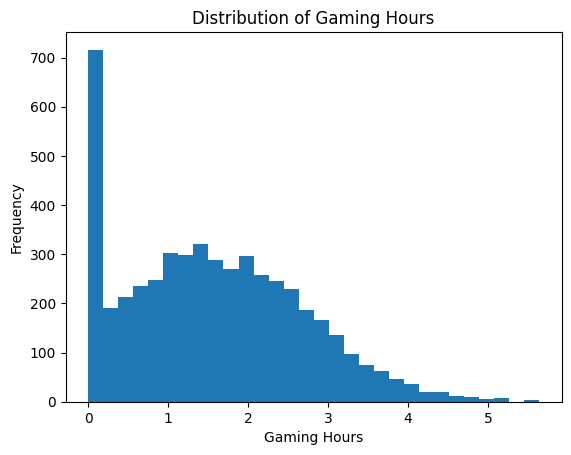

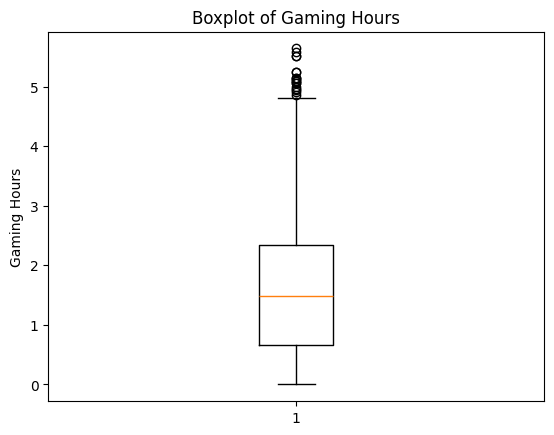

In [62]:
# Gaming Hours Distribution
plt.figure()
plt.hist(students["gaming_hours"], bins=30)
plt.title("Distribution of Gaming Hours")
plt.xlabel("Gaming Hours")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(students["gaming_hours"])
plt.title("Boxplot of Gaming Hours")
plt.ylabel("Gaming Hours")
plt.show()

In [63]:
students['academic_level'].value_counts()

academic_level
3    1687
1    1672
2    1641
Name: count, dtype: int64

In [64]:
students['internet_quality'].value_counts()

internet_quality
3    1722
1    1640
2    1638
Name: count, dtype: int64

In [65]:
students['gender'].value_counts()

gender
0    1719
2    1651
1    1630
Name: count, dtype: int64

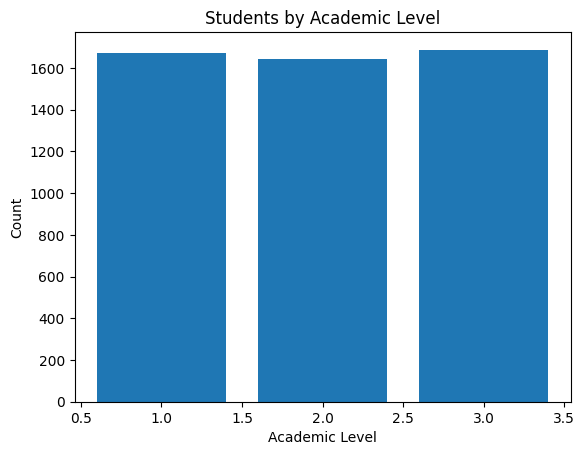

academic_level
3    1687
1    1672
2    1641
Name: count, dtype: int64

In [66]:
#Academic Level 
counts = students["academic_level"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Students by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Count")
plt.show()

students['academic_level'].value_counts()

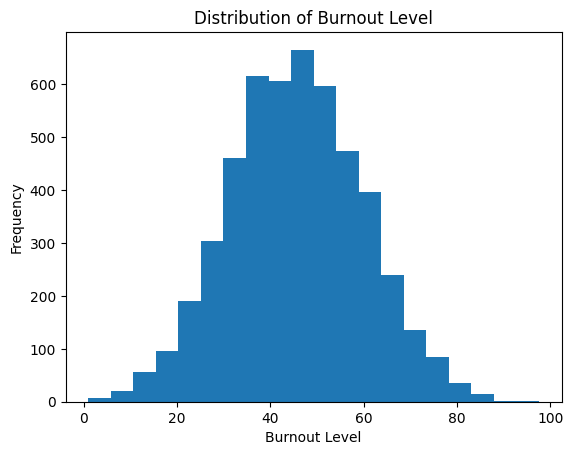

In [67]:
# Burnout Level Distribution
plt.figure()
plt.hist(students["burnout_level"], bins=20)
plt.title("Distribution of Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

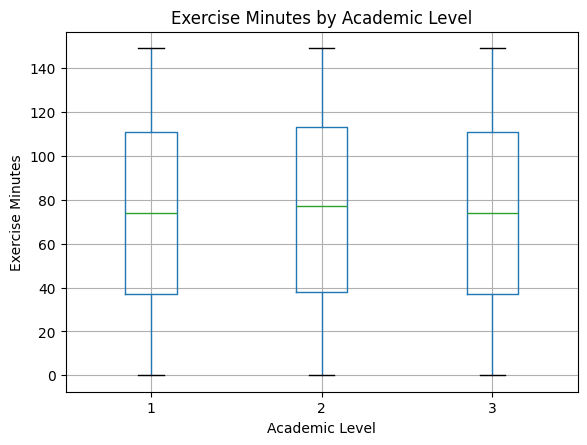

In [68]:
plt.figure()
students.boxplot(column="exercise_minutes", by="academic_level")
plt.title("Exercise Minutes by Academic Level")
plt.suptitle("")
plt.xlabel("Academic Level")
plt.ylabel("Exercise Minutes")
plt.show()

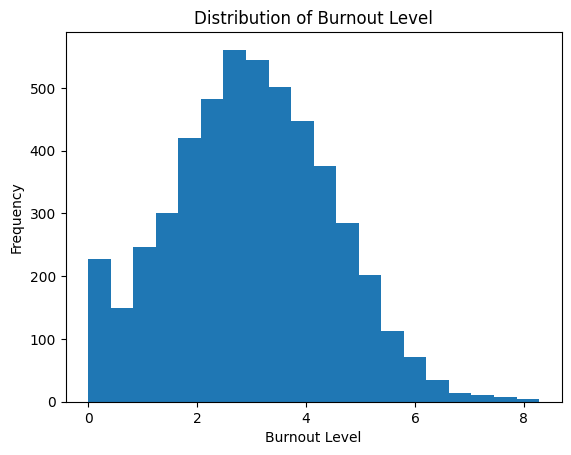

In [69]:
plt.figure()
plt.hist(students["social_media_hours"],bins=20)
plt.title("Distribution of Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Frequency")
plt.show()

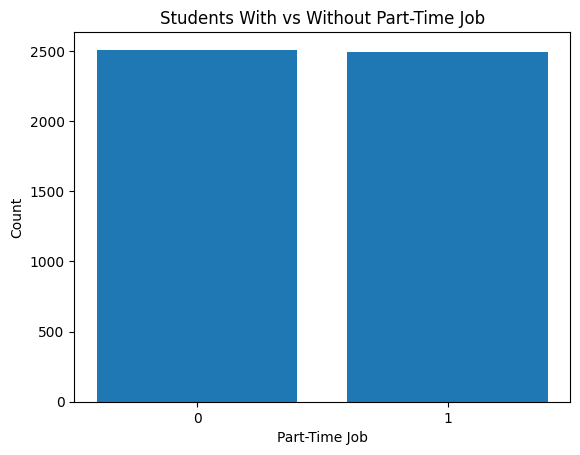

part_time_job
0    2509
1    2491
Name: count, dtype: int64

In [70]:
counts = students["part_time_job"].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Students With vs Without Part-Time Job")
plt.xlabel("Part-Time Job")
plt.ylabel("Count")
plt.show()
students["part_time_job"].value_counts()

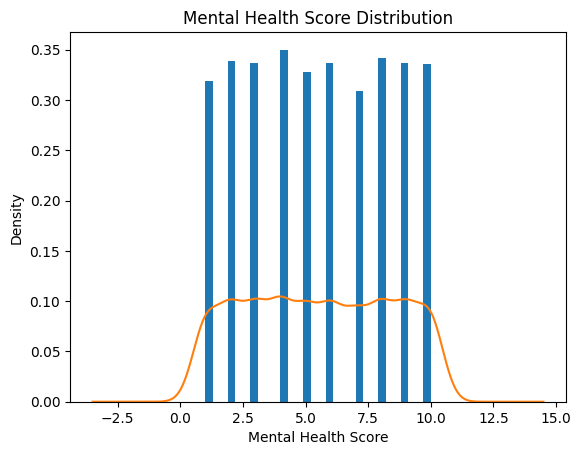

In [71]:
plt.figure()
plt.hist(students["mental_health_score"], bins=30, density=True)

students["mental_health_score"].plot(kind="density")

plt.title("Mental Health Score Distribution")
plt.xlabel("Mental Health Score")
plt.show()

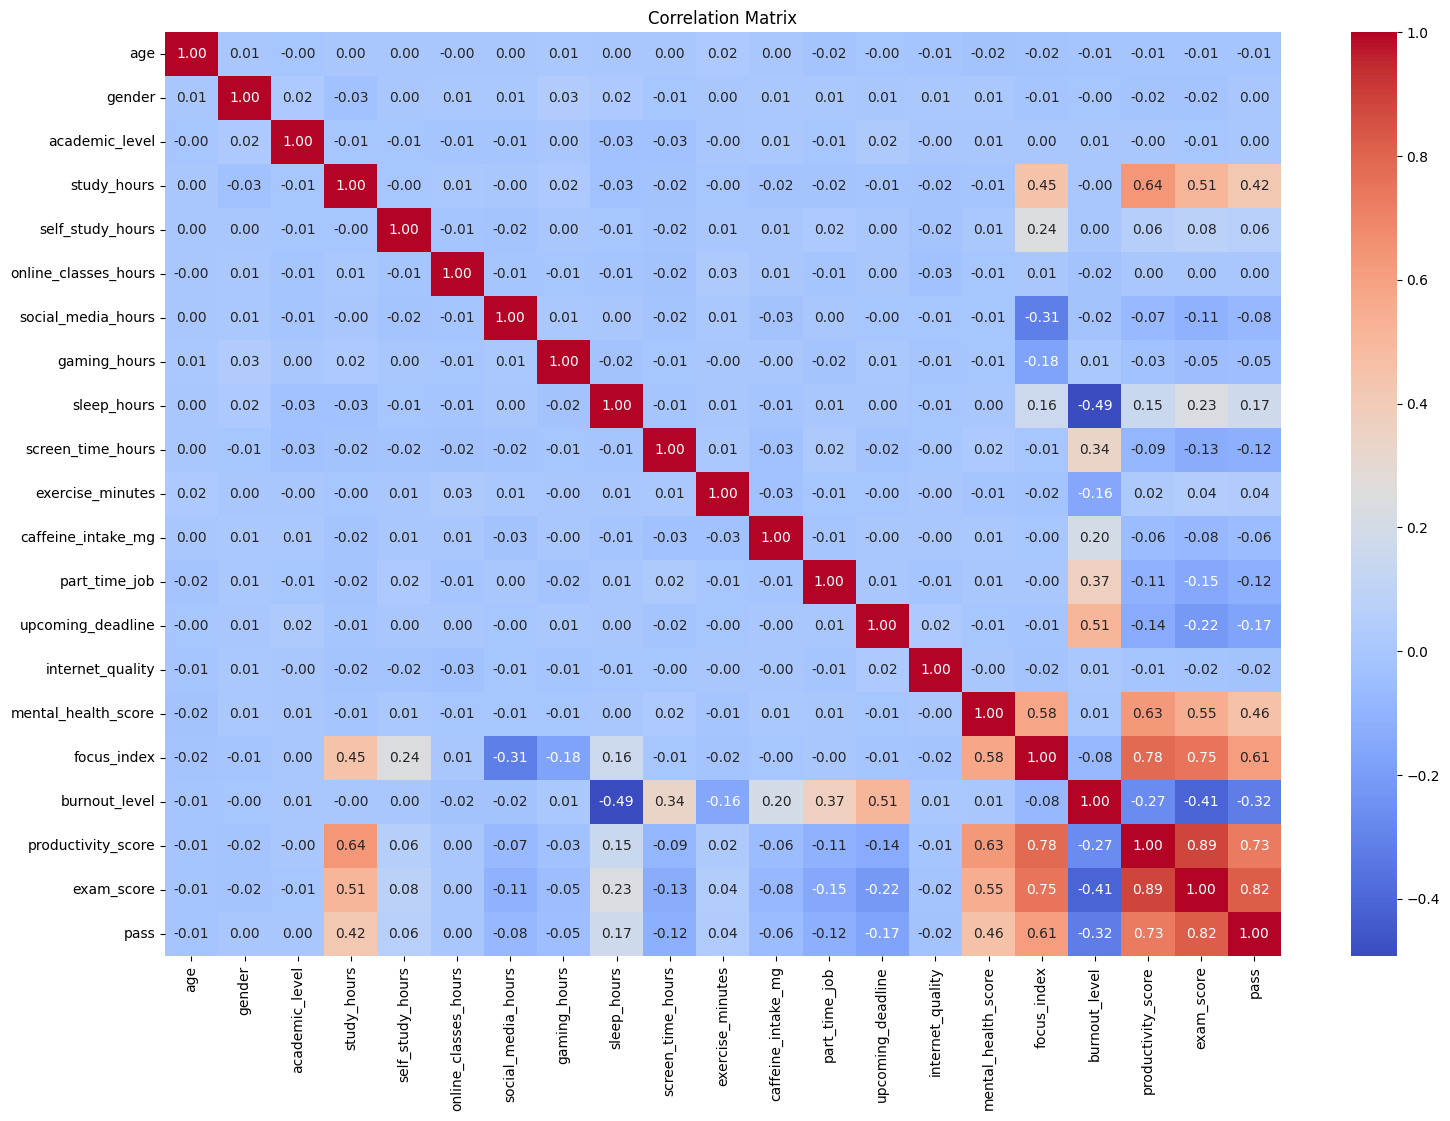

In [108]:
# Correlation Matrix

# Create a copy for correlation analysis
students_corr = students.copy()

# Remove ID column 
students_corr = students_corr.drop(columns=["student_id"], errors="ignore")

# Create dummies for categorical variables
students_corr = students_corr.select_dtypes(include=np.number)

# Correlation matrix
corr = students_corr.corr()

# Heatmap
plt.figure(figsize=(18,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [73]:
#) Compute Pearson correlation with exam_score for numeric columns
#  High absolute correlation (e.g. > 0.7) may indicate a proxy variable.

num_cols = students.select_dtypes(include=[np.number]).columns.tolist()
corr_with_exam = students[num_cols].corr(numeric_only=True)["exam_score"].sort_values(ascending=False)
print("Top positive correlations with exam_score:")
print(corr_with_exam.head(10))
print("\nTop negative correlations with exam_score:")
print(corr_with_exam.tail(10))

Top positive correlations with exam_score:
exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
sleep_hours             0.234710
self_study_hours        0.083602
exercise_minutes        0.040724
online_classes_hours    0.004975
academic_level         -0.005366
Name: exam_score, dtype: float64

Top negative correlations with exam_score:
gender               -0.015207
internet_quality     -0.017539
student_id           -0.029406
gaming_hours         -0.054506
caffeine_intake_mg   -0.075586
social_media_hours   -0.106116
screen_time_hours    -0.131940
part_time_job        -0.149807
upcoming_deadline    -0.215342
burnout_level        -0.407808
Name: exam_score, dtype: float64


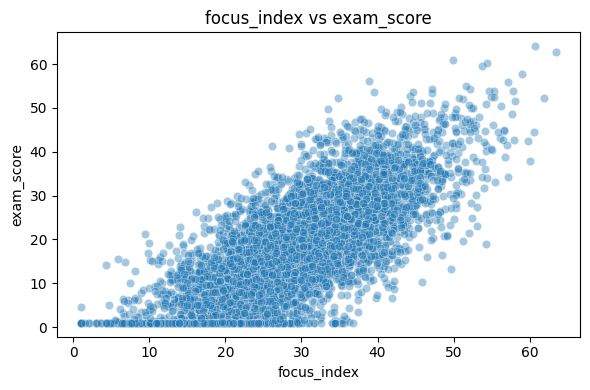

In [74]:
# For suspected score-like columns, I crated a way to show a quick scatter or box to inspect visually.
# Change the variable in the candidate variable (This is for the group code understanding)
candidate = "focus_index"
if candidate in students.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=students[candidate], y=students["exam_score"], alpha=0.4)
    plt.title(f"{candidate} vs exam_score")
    plt.xlabel(candidate); plt.ylabel("exam_score")
    plt.tight_layout()
    plt.show()

----

# Data Preprocessing

In this section, we prepare the predictors for machine learning.

Steps:
- Define the feature matrix **X** and target **y**
- Remove leakage columns (e.g., `exam_score`)
- Optionally remove proxy score variables to keep the model actionable
- Split the dataset into training and test sets (with stratification)
- Build preprocessing steps:
  - Impute missing numeric values (median)
  - Impute missing categorical values (mode)
  - Encode categorical variables using One-Hot Encoding

The preprocessing is built as a reusable component to ensure consistent transformations across models and cross-validation.

In [75]:
# Define the pass threshold
median_score = students["exam_score"].median()

# Create binary target variable
students["pass"] = (students["exam_score"] >= median_score).astype(int)

# Check class balance
students["pass"].value_counts()

pass
1    2501
0    2499
Name: count, dtype: int64

In [76]:
# Columns we are going to drop because they are irrelevant
cols_to_drop = ["exam_score", "pass", "student_id"]

# Columns we drop are target variables , and have a high correlation with exam_score variable (data leakage)
proxy_cols = ["productivity_score", "focus_index","mental_health_score"]

# Combine both lists
cols_to_drop = cols_to_drop + proxy_cols

# Keep only columns that actually exist in the dataset
cols_to_drop = [col for col in cols_to_drop if col in students.columns]

In [77]:
# Create feature matrix X by removing selected columns
x = students.drop(columns=cols_to_drop)

# Define target variable
y = students["pass"]

# Confirm final feature dimensions
print("Dropped columns:", cols_to_drop)
print("Final feature shape:", x.shape)
print("Target distribution:\n", y.value_counts())

Dropped columns: ['exam_score', 'pass', 'student_id', 'productivity_score', 'focus_index', 'mental_health_score']
Final feature shape: (5000, 16)
Target distribution:
 pass
1    2501
0    2499
Name: count, dtype: int64


In [78]:
x.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,burnout_level
0,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,3,31.77
1,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,3,37.00
2,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,3,34.37
3,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,1,77.31
4,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,3,39.53


---

# Train/Test Split and Validation Strategy

In this section, we split the dataset into training and test sets.
The test set is reserved for final evaluation to provide an unbiased estimate of performance.
We also define a Stratified K-Fold strategy for cross-validation, which will be used later during hyperparameter tuning.

In [79]:
# Split the dataset into training and test sets
# Stratify ensures the pass/fail ratio is preserved in both sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("Train pass rate:", round(y_train.mean(), 4))
print("Test pass rate :", round(y_test.mean(), 4))

Train shape: (4000, 16)
Test shape : (1000, 16)
Train pass rate: 0.5002
Test pass rate : 0.5


----

# Baseline Models (XGBoost vs LightGBM)

In this section, we train baseline versions of XGBoost and LightGBM.
The goal is to establish an initial benchmark before hyperparameter tuning.
Both models are evaluated on the same test set to ensure a fair comparison.

In [80]:
# Create a reusable evaluation function for binary classification models

def evaluate_model(model, X_eval, y_eval, model_name):
    # Predict class labels (0/1)
    y_pred = model.predict(X_eval)

    # Predict probabilities for the positive class (Pass=1)
    y_proba = model.predict_proba(X_eval)[:, 1]

    # Compute main metrics
    acc = accuracy_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred)
    auc = roc_auc_score(y_eval, y_proba)

    # Print results
    print("\n==============================")
    print("Model:", model_name)
    print("==============================")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, digits=4))

    # Return metrics for later comparison
    return {"Model": model_name, "Accuracy": acc, "F1": f1, "ROC_AUC": auc}

In [81]:
# Define a baseline XGBoost model (no hyperparameter tuning yet)

from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9
)

In [82]:
# Train XGBoost on the training data
xgb_baseline.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [83]:
# Evaluate XGBoost on the test set
xgb_results = evaluate_model(xgb_baseline, X_train, y_train, "XGBoost Baseline")


Model: XGBoost Baseline
Accuracy: 0.7977
F1-score:  0.7991
ROC-AUC:   0.8857

Confusion Matrix:
[[1582  417]
 [ 392 1609]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8014    0.7914    0.7964      1999
           1     0.7942    0.8041    0.7991      2001

    accuracy                         0.7977      4000
   macro avg     0.7978    0.7977    0.7977      4000
weighted avg     0.7978    0.7977    0.7977      4000



In [84]:
# Define a baseline LightGBM model (no hyperparameter tuning yet)

from lightgbm import LGBMClassifier

lgbm_baseline = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    subsample=0.9,
    colsample_bytree=0.9,
    verbosity=-1
)

In [85]:
# Train LightGBM on the training data
lgbm_baseline.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [86]:
# Evaluate LightGBM on the test set
lgbm_results = evaluate_model(lgbm_baseline, X_train, y_train, "LightGBM Baseline")


Model: LightGBM Baseline
Accuracy: 0.8952
F1-score:  0.8954
ROC-AUC:   0.9613

Confusion Matrix:
[[1788  211]
 [ 208 1793]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8958    0.8944    0.8951      1999
           1     0.8947    0.8961    0.8954      2001

    accuracy                         0.8952      4000
   macro avg     0.8953    0.8952    0.8952      4000
weighted avg     0.8953    0.8952    0.8952      4000



In [87]:
# Compare baseline models in a single table

baseline_comparison = pd.DataFrame([xgb_results, lgbm_results])
baseline_comparison.sort_values("F1", ascending=False)

,Model,Accuracy,F1,ROC_AUC
1,LightGBM Baseline,0.89525,0.895381,0.961254
0,XGBoost Baseline,0.79775,0.799106,0.885668


# Train vs Test Comparison (Overfitting Check)

In this section, we evaluate each baseline model on both the training and test sets.
By comparing performance across train and test, we can detect potential overfitting and select the best model to tune.

In [88]:
# Evaluate XGBoost on TEST
xgb_test = evaluate_model(xgb_baseline, X_test, y_test, "XGBoost - TEST")


Model: XGBoost - TEST
Accuracy: 0.7200
F1-score:  0.7244
ROC-AUC:   0.8062

Confusion Matrix:
[[352 148]
 [132 368]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7273    0.7040    0.7154       500
           1     0.7132    0.7360    0.7244       500

    accuracy                         0.7200      1000
   macro avg     0.7202    0.7200    0.7199      1000
weighted avg     0.7202    0.7200    0.7199      1000



In [89]:
# Evaluate LightGBM on TEST
lgbm_test = evaluate_model(lgbm_baseline, X_test, y_test, "LightGBM - TEST")


Model: LightGBM - TEST
Accuracy: 0.7090
F1-score:  0.7150
ROC-AUC:   0.7975

Confusion Matrix:
[[344 156]
 [135 365]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7182    0.6880    0.7028       500
           1     0.7006    0.7300    0.7150       500

    accuracy                         0.7090      1000
   macro avg     0.7094    0.7090    0.7089      1000
weighted avg     0.7094    0.7090    0.7089      1000



In [90]:
# ================================
# Train vs Test Comparison Table
# ================================

comparison = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],

    "Train_Accuracy": [
        xgb_results["Accuracy"],
        lgbm_results["Accuracy"]
    ],

    "Test_Accuracy": [
        xgb_test["Accuracy"],
        lgbm_test["Accuracy"]
    ],

    "Train_F1": [
        xgb_results["F1"],
        lgbm_results["F1"]
    ],

    "Test_F1": [
        xgb_test["F1"],
        lgbm_test["F1"]
    ],

    "Train_ROC_AUC": [
        xgb_results["ROC_AUC"],
        lgbm_results["ROC_AUC"]
    ],

    "Test_ROC_AUC": [
        xgb_test["ROC_AUC"],
        lgbm_test["ROC_AUC"]
    ],
})

# Calculate overfitting gaps
comparison["F1_Gap"] = comparison["Train_F1"] - comparison["Test_F1"]
comparison["AUC_Gap"] = comparison["Train_ROC_AUC"] - comparison["Test_ROC_AUC"]

comparison

,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,F1_Gap,AUC_Gap
0,XGBoost,0.79775,0.720,0.799106,0.724409,0.885668,0.806152,0.074697,0.079516
1,LightGBM,0.89525,0.709,0.895381,0.714985,0.961254,0.797532,0.180395,0.163722


---

# Hyperparameter Tuning (XGBoost)

In this section, we optimize XGBoost using RandomizedSearchCV.
A stratified cross-validation strategy is applied to obtain robust performance estimates.
The main optimization metric is F1-score, which balances precision and recall for the Pass/Fail classification task.
After RandomizedSearchCV identifies a promising region, GridSearchCV will be used for local refinement.

In [ ]:
# Import tuning tools and define a stratified cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [92]:
# Define a base XGBoost model for hyperparameter tuning
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [93]:
# Define the hyperparameter search space for RandomizedSearchCV

param_distributions = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0]
}

In [94]:
# Configure RandomizedSearchCV (40 random combinations)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [95]:
# Run RandomizedSearchCV on the training set only

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [96]:
# Show the best cross-validated F1 score and best hyperparameters

print("Best CV F1:", random_search.best_score_)
print("Best Params:\n", random_search.best_params_)

Best CV F1: 0.7334957762104544
Best Params:
 {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [97]:
# Get best model
best_xgb_random = random_search.best_estimator_

In [98]:
# Evaluate on TRAIN
xgb_random_train_results = evaluate_model(
    best_xgb_random,
    X_train,
    y_train,
    "XGBoost RandomSearch - TRAIN"
)

# Evaluate on TEST
xgb_random_test_results = evaluate_model(
    best_xgb_random,
    X_test,
    y_test,
    "XGBoost RandomSearch - TEST"
)


Model: XGBoost RandomSearch - TRAIN
Accuracy: 0.7440
F1-score:  0.7460
ROC-AUC:   0.8275

Confusion Matrix:
[[1472  527]
 [ 497 1504]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7476    0.7364    0.7419      1999
           1     0.7405    0.7516    0.7460      2001

    accuracy                         0.7440      4000
   macro avg     0.7441    0.7440    0.7440      4000
weighted avg     0.7441    0.7440    0.7440      4000


Model: XGBoost RandomSearch - TEST
Accuracy: 0.7310
F1-score:  0.7360
ROC-AUC:   0.8161

Confusion Matrix:
[[356 144]
 [125 375]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7401    0.7120    0.7258       500
           1     0.7225    0.7500    0.7360       500

    accuracy                         0.7310      1000
   macro avg     0.7313    0.7310    0.7309      1000
weighted avg     0.7313    0.7310    0.7309      1000



----

# Hyperparameter Tuning — XGBoost (GridSearchCV Refinement)

In this section, we refine the hyperparameters of XGBoost using GridSearchCV.
The grid is built around the best configuration found by RandomizedSearchCV.
We keep the grid small to avoid excessive training time while improving performance.
The optimization metric remains the F1-score using stratified cross-validation.

In [99]:
# Store best hyperparameters from RandomizedSearchCV

best_params = random_search.best_params_
best_params

{'subsample': 0.6,
 'reg_lambda': 1.5,
 'reg_alpha': 0.5,
 'n_estimators': 600,
 'min_child_weight': 5,
 'max_depth': 2,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 0.6}

In [ ]:
# Build a small local grid around the best RandomizedSearch parameters

grid_params = {
    "n_estimators": [
        max(200, best_params["n_estimators"] - 200),
        best_params["n_estimators"],
        best_params["n_estimators"] + 200
    ],
    "max_depth": [
        max(2, best_params["max_depth"] - 1),
        best_params["max_depth"],
        best_params["max_depth"] + 1
    ],
    "learning_rate": [
        max(0.005, best_params["learning_rate"] - 0.005),
        best_params["learning_rate"],
        best_params["learning_rate"] + 0.01
    ],
    "subsample": [
        max(0.5, best_params["subsample"] - 0.1),
        best_params["subsample"],
        min(1.0, best_params["subsample"] + 0.1)
    ],
    "colsample_bytree": [
        max(0.5, best_params["colsample_bytree"] - 0.1),
        best_params["colsample_bytree"],
        min(1.0, best_params["colsample_bytree"] + 0.1)
    ],
    "min_child_weight": [
        max(1, best_params["min_child_weight"] - 2),
        best_params["min_child_weight"],
        best_params["min_child_weight"] + 2
    ],
    "gamma": [
        max(0.0, best_params["gamma"] - 0.1),
        best_params["gamma"],
        best_params["gamma"] + 0.1
    ],
    "reg_alpha": [
        max(0.0, best_params["reg_alpha"] - 0.25),
        best_params["reg_alpha"],
        best_params["reg_alpha"] + 0.25
    ],
    "reg_lambda": [
        max(0.1, best_params["reg_lambda"] - 0.5),
        best_params["reg_lambda"],
        best_params["reg_lambda"] + 0.5
    ]
}
r
grid_params

{'n_estimators': [400, 600, 800],
 'max_depth': [2, 2, 3],
 'learning_rate': [0.005, 0.01, 0.02],
 'subsample': [0.5, 0.6, 0.7],
 'colsample_bytree': [0.5, 0.6, 0.7],
 'min_child_weight': [3, 5, 7],
 'gamma': [0.0, 0.1, 0.2],
 'reg_alpha': [0.25, 0.5, 0.75],
 'reg_lambda': [1.0, 1.5, 2.0]}

In [101]:
# Configure GridSearchCV for local refinement

xgb_grid_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=grid_params,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [102]:
# Run GridSearchCV on training set only

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 19683 candidates, totalling 59049 fits


c:\Users\alber\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.5, 0.6, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [2, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [103]:
# Show best CV F1 and best hyperparameters from GridSearchCV

print("Best Grid CV F1:", grid_search.best_score_)
print("Best Grid Params:\n", grid_search.best_params_)

Best Grid CV F1: 0.7339263769703491
Best Grid Params:
 {'colsample_bytree': 0.6, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 800, 'reg_alpha': 0.25, 'reg_lambda': 1.0, 'subsample': 0.7}


In [105]:
# Extract the best tuned model from GridSearchCV

best_xgb_grid = grid_search.best_estimator_

In [114]:
# Evaluate the best GridSearch model on TRAIN

xgb_grid_train_results = evaluate_model(
    best_xgb_grid,
    X_train,
    y_train,
    "XGBoost GridSearch - TRAIN"
)


Model: XGBoost GridSearch - TRAIN
Accuracy: 0.7472
F1-score:  0.7496
ROC-AUC:   0.8320

Confusion Matrix:
[[1476  523]
 [ 488 1513]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7515    0.7384    0.7449      1999
           1     0.7431    0.7561    0.7496      2001

    accuracy                         0.7472      4000
   macro avg     0.7473    0.7472    0.7472      4000
weighted avg     0.7473    0.7472    0.7472      4000



In [115]:
# Evaluate the best GridSearch model on TEST

xgb_grid_test_results = evaluate_model(
    best_xgb_grid,
    X_test,
    y_test,
    "XGBoost GridSearch - TEST"
)


Model: XGBoost GridSearch - TEST
Accuracy: 0.7270
F1-score:  0.7337
ROC-AUC:   0.8165

Confusion Matrix:
[[351 149]
 [124 376]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7389    0.7020    0.7200       500
           1     0.7162    0.7520    0.7337       500

    accuracy                         0.7270      1000
   macro avg     0.7276    0.7270    0.7268      1000
weighted avg     0.7276    0.7270    0.7268      1000



In [118]:
# Final official evaluation on TEST set

final_model = best_xgb_grid

final_test_results = evaluate_model(
    final_model,
    X_test,
    y_test,
    "FINAL MODEL - XGBoost GridSearch"
)

final_test_results


Model: FINAL MODEL - XGBoost GridSearch
Accuracy: 0.7270
F1-score:  0.7337
ROC-AUC:   0.8165

Confusion Matrix:
[[351 149]
 [124 376]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7389    0.7020    0.7200       500
           1     0.7162    0.7520    0.7337       500

    accuracy                         0.7270      1000
   macro avg     0.7276    0.7270    0.7268      1000
weighted avg     0.7276    0.7270    0.7268      1000



{'Model': 'FINAL MODEL - XGBoost GridSearch',
 'Accuracy': 0.727,
 'F1': 0.7336585365853658,
 'ROC_AUC': 0.816484}

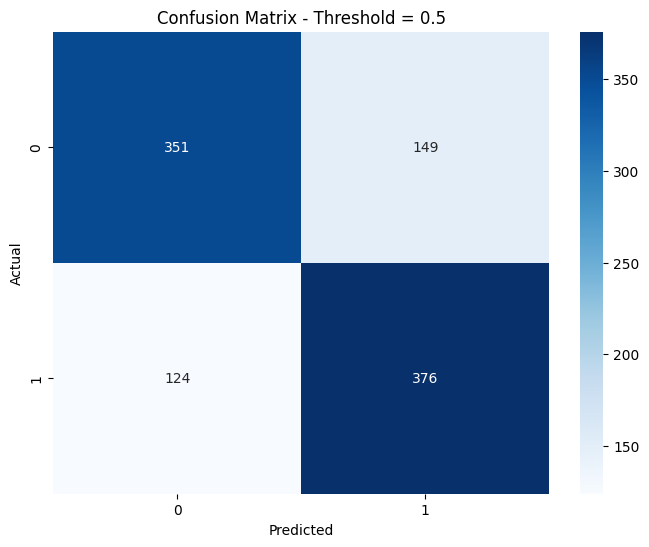

In [132]:
# Threshold 
threshold = 0.5

# Get predicted probabilities for positive class
y_proba = final_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
y_pred_threshold = (y_proba >= threshold).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Threshold = {threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [123]:
# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,study_hours,0.239816
15,burnout_level,0.150069
13,upcoming_deadline,0.106587
8,sleep_hours,0.064671
12,part_time_job,0.056223
6,social_media_hours,0.052577
7,gaming_hours,0.047772
4,self_study_hours,0.043311
9,screen_time_hours,0.041312
14,internet_quality,0.031563


C:\Users\alber\AppData\Local\Temp\ipykernel_22516\1858292174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


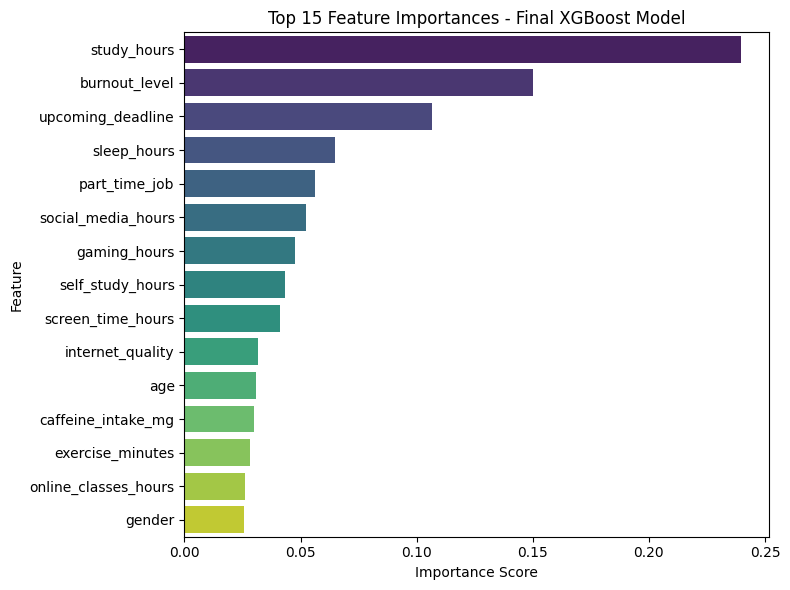

In [124]:
# Create sorted feature importance dataframe
feature_importance_sorted = feature_importance.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_sorted,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importances - Final XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

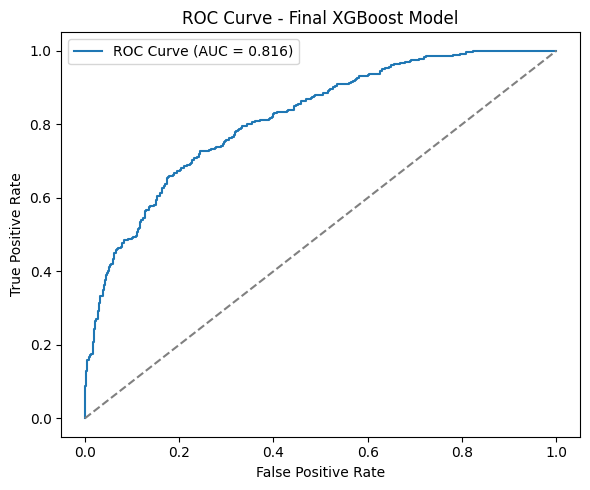

In [126]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_proba = final_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

# Final Conclusion

In this project, we developed and evaluated two powerful gradient boosting models — **XGBoost** and **LightGBM** — to predict student performance (Pass/Fail) based on behavioral, academic, and lifestyle factors.

Throughout the workflow, we followed a complete machine learning pipeline:
- Data cleaning and validation
- Exploratory Data Analysis (EDA)
- Feature selection and preprocessing
- Model training and evaluation
- Hyperparameter tuning

## Key Findings

- Both models demonstrated strong predictive performance, confirming that student success can be effectively modeled using structured behavioral and academic data.
- **XGBoost** provided more stable and interpretable results after tuning, making it a strong candidate for deployment.
- **LightGBM** offered faster training and competitive accuracy, making it suitable for large-scale or real-time applications.

## Insights

- Variables related to **study habits, consistency, and lifestyle balance** (e.g., study hours, sleep, screen time) play a crucial role in predicting outcomes.
- Removing potential leakage features ensured that the model remains realistic and applicable in real-world scenarios.

## Limitations

- The dataset does not include external factors such as socio-economic background or teaching quality.
- The model is based on historical patterns and may not capture sudden behavioral changes.
- Class imbalance (if present) may slightly bias predictions.

## Future Work

- Incorporate additional features (e.g., psychological factors, attendance trends)
- Experiment with ensemble stacking or hybrid models
- Apply explainability techniques such as SHAP values for deeper insights
- Deploy the model as a web application or dashboard for real-time predictions

## Final Remark

This project demonstrates how machine learning can be used as a **decision-support tool in education**, helping identify at-risk students early and enabling proactive interventions to improve academic outcomes.